# Quadratic in log-price

Synthetic data uses `shape="quadratic"` (curvature in log-price). We fit **`QuadraticLogDemandModel`** (generative model) and **`LogLogDemandModel`** (misspecified) and compare response curves for one SKU.

From the repository root:

```bash
uv sync
```

MCMC settings in these notebooks use small `draws` / `tune` / `chains` for quick runs. Increase them for production-quality inference.


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_sku, elasticity_sku, curvature_sku, sigma, beta_control]
Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_sku, elasticity_sku, sigma, beta_control]
Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 1 seconds.


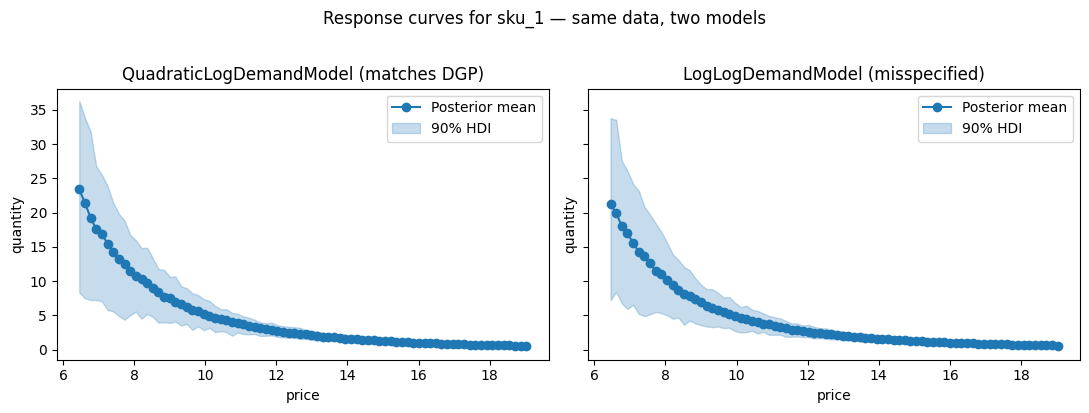

In [3]:
import warnings

warnings.filterwarnings("ignore", message=".*IProgress not found.*")

import matplotlib.pyplot as plt
import numpy as np

from pypricing import (
    LogLogDemandModel,
    QuadraticLogDemandModel,
    generate_mock_data,
)


def controls_for_sku(df, model, sku):
    if not model.control_names_:
        return None
    sub = df[df[model.sku_col] == sku]
    return {c: float(sub[c].median()) for c in model.control_names_}


n_periods, n_skus, seed = 14, 4, 123

df_q = generate_mock_data(
    n_periods=n_periods,
    n_skus=n_skus,
    n_controls=1,
    random_state=seed,
    shape="quadratic",
)

fit_kw = dict(
    draws=120,
    tune=120,
    chains=2,
    random_seed=0,
    progressbar=False,
    compute_convergence_checks=False,
)

model_q = QuadraticLogDemandModel()
model_q.fit(df_q, **fit_kw)

model_ll = LogLogDemandModel()
model_ll.fit(df_q, **fit_kw)

sku0 = model_q.sku_levels_[0]
lo = float(df_q.loc[df_q[model_q.sku_col] == sku0, model_q.price_col].min()) * 0.5
hi = float(df_q.loc[df_q[model_q.sku_col] == sku0, model_q.price_col].max()) * 1.2
price_grid = np.linspace(lo, hi, 80)
ctrl = controls_for_sku(df_q, model_q, sku0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
model_q.plot_response_curve(
    sku=sku0,
    price_grid=price_grid,
    controls=ctrl,
    hdi_prob=0.9,
    ax=axes[0],
)
axes[0].set_title("QuadraticLogDemandModel (matches DGP)")

model_ll.plot_response_curve(
    sku=sku0,
    price_grid=price_grid,
    controls=ctrl,
    hdi_prob=0.9,
    ax=axes[1],
)
axes[1].set_title("LogLogDemandModel (misspecified)")

fig.suptitle(f"Response curves for {sku0} — same data, two models", y=1.02)
plt.tight_layout()
plt.show()

## Holdout error (same split)

Rough comparison of out-of-sample quantity error when the DGP is quadratic.


In [4]:
tt_kw = dict(
    test_size=0.25,
    period_col="period",
    hdi_prob=0.9,
    draws=120,
    tune=120,
    chains=2,
    random_seed=seed,
    progressbar=False,
    compute_convergence_checks=False,
)
out_q = QuadraticLogDemandModel().fit_train_test(df_q, **tt_kw)
out_ll = LogLogDemandModel().fit_train_test(df_q, **tt_kw)
print(
    "RMSE (quantity, test):",
    out_q["rmse"],
    "(quadratic)",
    "|",
    out_ll["rmse"],
    "(log-log)",
)
print("HDI coverage:", out_q["hdi_coverage"], "|", out_ll["hdi_coverage"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_sku, elasticity_sku, curvature_sku, sigma, beta_control]
Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_sku, elasticity_sku, sigma, beta_control]
Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 1 seconds.


RMSE (quantity, test): 31.21886009177662 (quadratic) | 31.33973149923115 (log-log)
HDI coverage: 0.9375 | 0.8125
